In [1]:
from PIL import Image
from torchvision.transforms import v2
from torchvision.transforms.functional import to_pil_image
import random

from src.mnist import get_dataset, PadAndEmbed

In [2]:
ds = get_dataset(True, v2.ToTensor())

ds_embed = get_dataset(True, v2.Compose([v2.ToTensor(), PadAndEmbed()]))

ds[0]

/home/asfaloth/trabajo_fin_grado/env/lib/python3.12/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

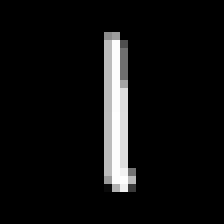

^ 1


In [3]:
img, label = ds[random.randint(0, len(ds)-1)]

def show_img(img, caption, scale:int=8):
    pil_img = to_pil_image(img)
    _, w, h = img.shape
    display(pil_img.resize((w*scale, h*scale), Image.NEAREST))
    print('^', caption)

show_img(img, label)

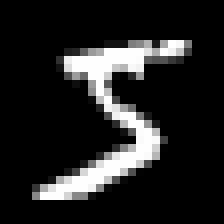

^ No padding


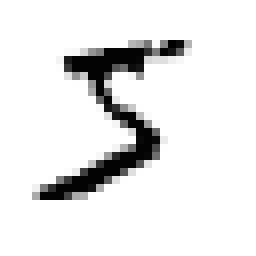

^ Padded, channel 0


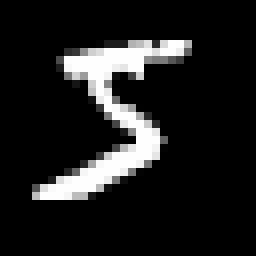

^ Padded, channel 1


In [4]:
img = ds[0][0]
show_img(img, 'No padding')

padded_img = ds_embed[0][0]

show_img(padded_img[0].unsqueeze(0), 'Padded, channel 0')
show_img(padded_img[1].unsqueeze(0), 'Padded, channel 1')

In [5]:
padded_img.flatten(1).shape

torch.Size([2, 1024])

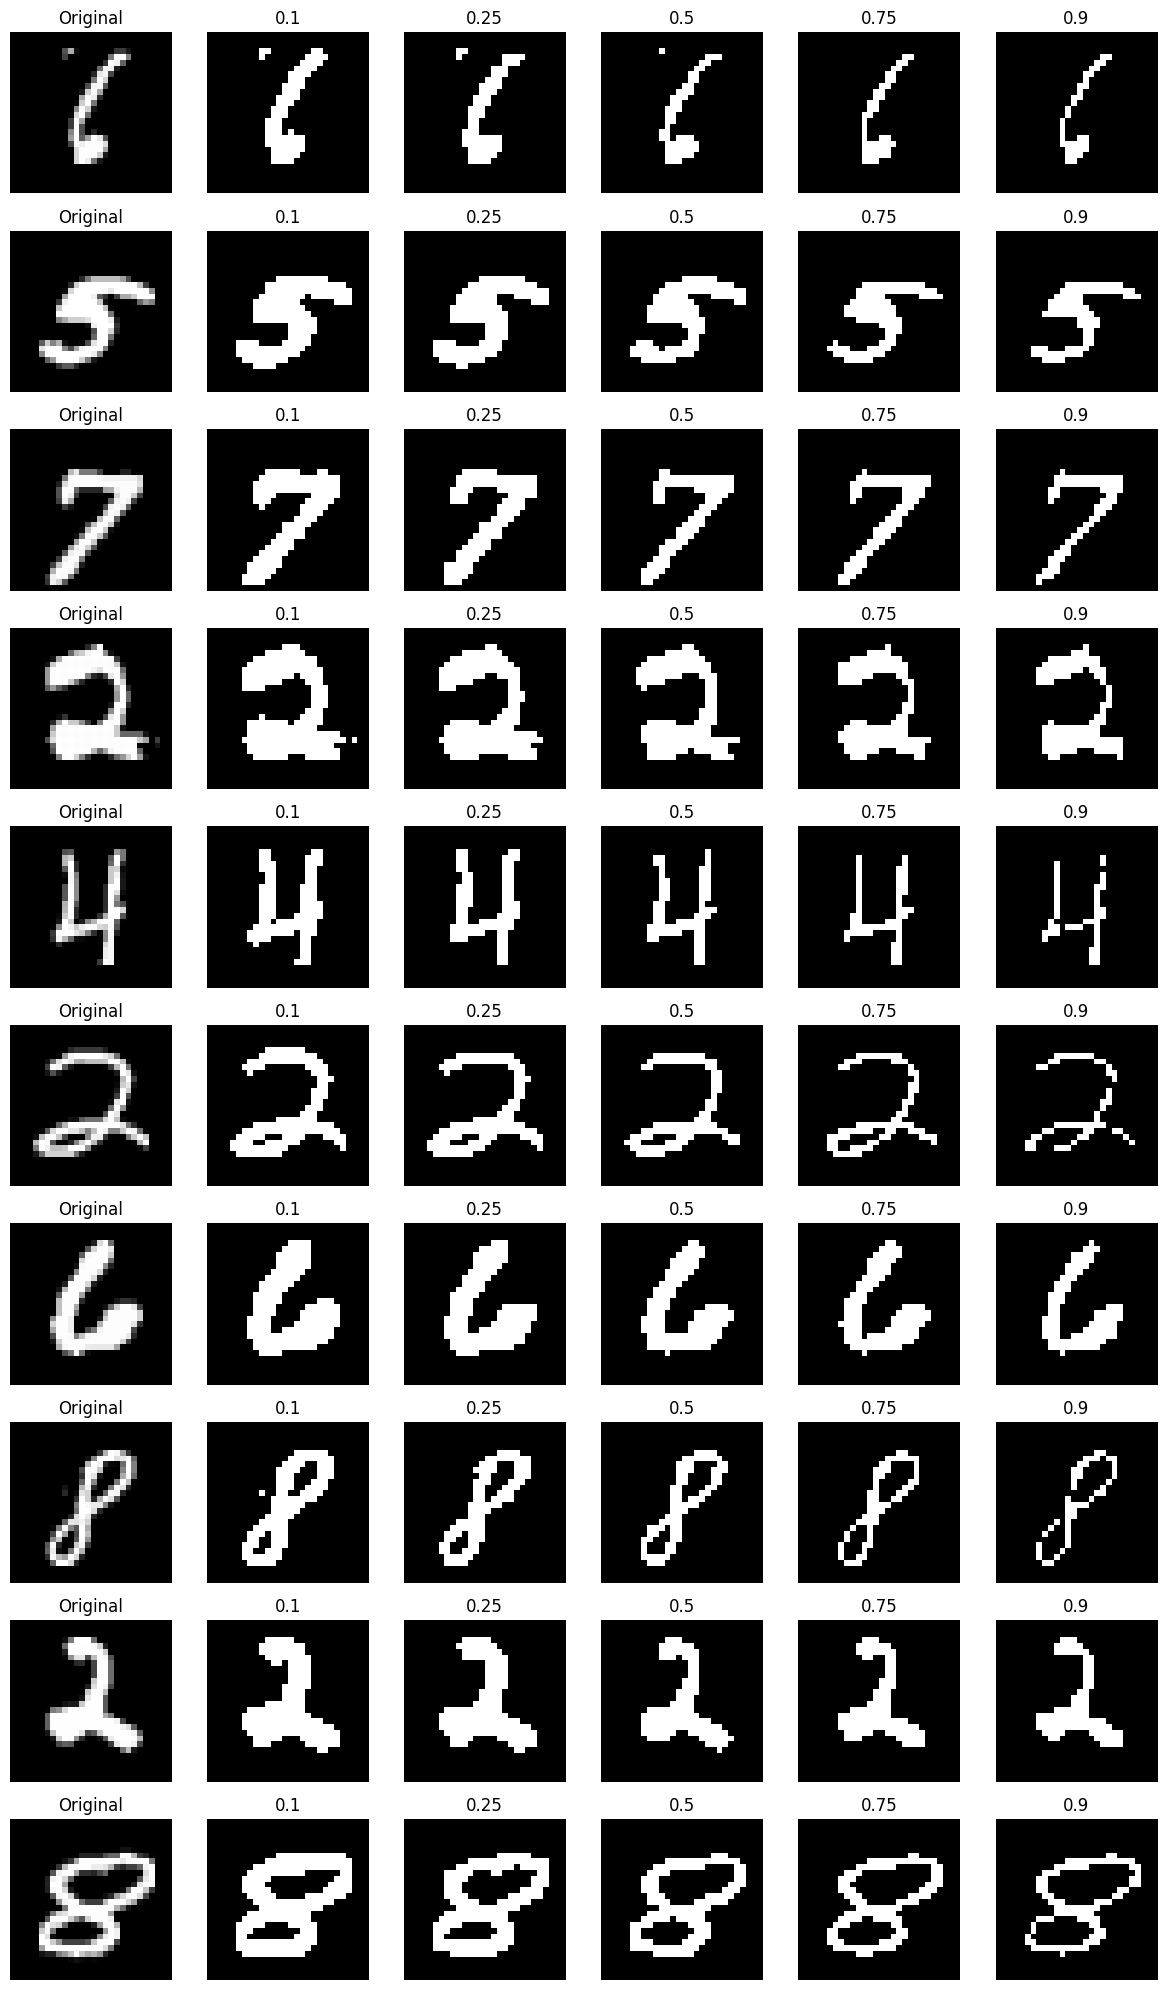

In [6]:
import matplotlib.pyplot as plt
import random

thresholds = [0.1, 0.25, 0.5, 0.75, 0.9]

n_samples = 10
n_cols = 1 + len(thresholds)

fig, axes = plt.subplots(n_samples, n_cols, figsize=(2*n_cols, 2*n_samples))

for row in range(n_samples):

    img, label = ds[random.randint(0, len(ds)-1)]
    img = img.squeeze()

    axes[row,0].imshow(img, cmap="gray")
    axes[row,0].set_title("Original")
    axes[row,0].axis("off")

    for col, thr in enumerate(thresholds, start=1):

        quant_img = (img > thr) * 1.0

        axes[row,col].imshow(quant_img, cmap="gray")
        axes[row,col].set_title(f"{thr}")
        axes[row,col].axis("off")

plt.tight_layout()
plt.show()

Loaded model


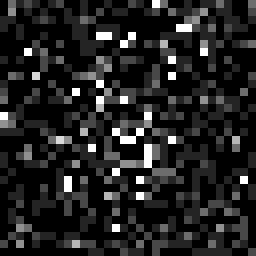

^ Generated image


In [31]:
from src.model import BinaryTTN
from src.generation_loop import sample_img
import torch
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

FILE_PATH = './saved_models/bond_16_new/epoch_30.pt'
N_VALUES = 8
TEMPERATURE = 0.1

model = BinaryTTN.from_file(FILE_PATH).to(device)

print('Loaded model')
generated_img = sample_img(model, n_values=N_VALUES, temperature=TEMPERATURE)

show_img(generated_img.unsqueeze(0), 'Generated image', scale=8)

In [ ]:
generated_img_2 = sample_img(model, n_values=N_VALUES, temperature=TEMPERATURE)
(generated_img - generated_img_2).abs().mean()

tensor(0.0264)